In [3]:
import pandas as pd
from pathlib import Path

In [4]:
LME = Path.cwd() / "data" / "lme_aluminium.csv"
MWP_M = Path.cwd() / "data" / "midwest_premium.csv"
US_IMPORTS = Path.cwd() / "data" / "us_imports_by_country.csv"
MWP_FUTURES= Path.cwd() / "data" / "midwest_premium_curve.csv"
DUP = Path.cwd() / "data" / "europe_duty_unpaid_premium.csv"
DP = Path.cwd() / "data" / "europe_duty_paid_premium.csv"
CANADA_EXPORTS = Path.cwd() / "data" / "anada_exports_by_country.csv"

In [5]:
lme = pd.read_csv(LME)
mwp_m = pd.read_csv(MWP_M)
mwp_futures = pd.read_csv(MWP_FUTURES)
dp = pd.read_csv(DP)

lme['date'] = pd.to_datetime(lme['date'])
mwp_m['date'] = pd.to_datetime(mwp_m['date'])
mwp_futures['date'] = pd.to_datetime(mwp_futures['date'])
dp['date'] = pd.to_datetime(dp['date'])

In [6]:
lme.columns

Index(['date', 'cash', 'three_month', 'stock'], dtype='object')

In [7]:
# Look at the landed cost (LME + DP + freight + tariff) vs. MW physical (LME + MWP)
# Before and after tariffs in june 4 2025

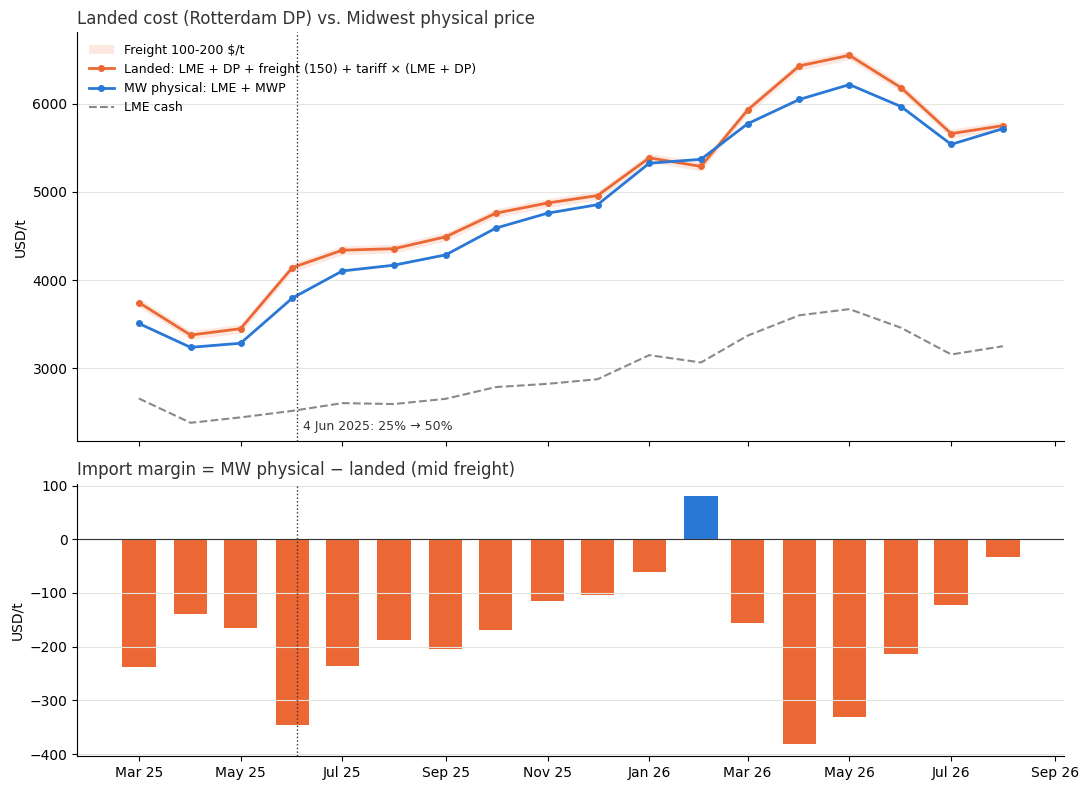

,before (Apr-May 25),after (Jul 25 on),change
mw_physical,3260.0,5194.0,1934.0
landed,3413.0,5354.0,1941.0
gap,-152.0,-160.0,-8.0
mwp,848.0,2119.0,1271.0
tariff,653.0,1735.0,1082.0


In [8]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Freight Rotterdam -> Midwest (USD/t): assumption, no free series. Mid + low/high band.
FREIGHT_LOW, FREIGHT_MID, FREIGHT_HIGH = 100, 150, 200
TARIFF_DATE = pd.Timestamp("2025-06-04")

# Monthly averages (month start index)
lme_m = lme.set_index("date")["cash"].resample("MS").mean().rename("lme")
dp_m = dp.set_index("date")["premium_usd_t"].rename("dp")
mwp_hist = mwp_m.set_index("date")["premium_usd_t"]
# Extend MWP past USGS coverage with the M01 futures settle at month-end
m01 = (mwp_futures[mwp_futures["tenor"] == 1].set_index("date")["premium_usd_t"]
       .resample("MS").last())
mwp_all = mwp_hist.combine_first(m01).rename("mwp")

df = pd.concat([lme_m, dp_m, mwp_all], axis=1).dropna()

# Tariff rate: 25% before 4 Jun 2025, 50% from then. June 2025 is day-weighted.
def tariff_rate(month_start):
    days = pd.date_range(month_start, month_start + pd.offsets.MonthEnd(0), freq="D")
    return ((days >= TARIFF_DATE) * 0.50 + (days < TARIFF_DATE) * 0.25).mean()

df["tariff_rate"] = [tariff_rate(d) for d in df.index]
df["fob"] = df["lme"] + df["dp"]
df["tariff"] = df["tariff_rate"] * df["fob"]
df["landed"] = df["fob"] + FREIGHT_MID + df["tariff"]
df["landed_low"] = df["fob"] + FREIGHT_LOW + df["tariff"]
df["landed_high"] = df["fob"] + FREIGHT_HIGH + df["tariff"]
df["mw_physical"] = df["lme"] + df["mwp"]
df["gap"] = df["mw_physical"] - df["landed"]   # >0: importing pays; <0: tariff not fully passed through

# The 25% rate only applied to all origins from 12 Mar 2025, so start the window there
plot = df.loc["2025-03-01":]

BLUE, ORANGE, INK, MUTED = "#2a78d6", "#eb6834", "#333333", "#8a8a85"
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8), sharex=True,
                               gridspec_kw={"height_ratios": [3, 2]})

ax1.fill_between(plot.index, plot["landed_low"], plot["landed_high"], color=ORANGE, alpha=0.15, lw=0,
                 label=f"Freight {FREIGHT_LOW}-{FREIGHT_HIGH} $/t")
ax1.plot(plot.index, plot["landed"], color=ORANGE, lw=2, marker="o", ms=4,
         label=f"Landed: LME + DP + freight ({FREIGHT_MID}) + tariff × (LME + DP)")
ax1.plot(plot.index, plot["mw_physical"], color=BLUE, lw=2, marker="o", ms=4,
         label="MW physical: LME + MWP")
ax1.plot(plot.index, plot["lme"], color=MUTED, lw=1.5, ls="--", label="LME cash")
ax1.set_ylabel("USD/t")
ax1.set_title("Landed cost (Rotterdam DP) vs. Midwest physical price", loc="left", color=INK)
ax1.legend(loc="upper left", frameon=False, fontsize=9)

gap_colors = [BLUE if g >= 0 else ORANGE for g in plot["gap"]]
ax2.bar(plot.index, plot["gap"], width=20, color=gap_colors)
ax2.axhline(0, color=INK, lw=0.8)
ax2.set_ylabel("USD/t")
ax2.set_title("Import margin = MW physical − landed (mid freight)", loc="left", color=INK)

for ax in (ax1, ax2):
    ax.axvline(TARIFF_DATE, color=INK, lw=1, ls=":")
    ax.grid(axis="y", color="#e5e5e0", lw=0.8)
    ax.spines[["top", "right"]].set_visible(False)
ax1.annotate("4 Jun 2025: 25% → 50%", xy=(TARIFF_DATE, ax1.get_ylim()[0]), xytext=(4, 8),
             textcoords="offset points", fontsize=9, color=INK)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))
fig.tight_layout()
plt.show()

# Average levels before / after the 4 Jun step (full months only)
pre, post = df.loc["2025-04-01":"2025-05-01"], df.loc["2025-07-01":]
summary = pd.DataFrame({"before (Apr-May 25)": pre[["mw_physical", "landed", "gap", "mwp", "tariff"]].mean(),
                        "after (Jul 25 on)": post[["mw_physical", "landed", "gap", "mwp", "tariff"]].mean()}).round(0)
summary["change"] = summary.iloc[:, 1] - summary.iloc[:, 0]
summary

takeaway: physical and landed price rose together, respectively by 1934$ and 1941$, indicating full passthrough of tariff costs. However, the import margin is still negative. One thing to note is that the import margin has a magnitude of 100-200 for most months, which is the same magnitude as the freight cost assumption, so changes in the freight cost can significantly alter the margins.

note: MWP after june 2026 is the front-month futures settle at month-end (since USGS monthly series stops at june 2026)